In [1]:
pip install shap

  Using cached shap-0.52.0-cp312-abi3-win_amd64.whl.metadata (26 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
Using cached shap-0.52.0-cp312-abi3-win_amd64.whl (499 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)

  Attempting uninstall: joblib

    Found existing installation: joblib 1.1.1

   ------------- -------------------------- 1/3 [joblib]
    Uninstalling joblib-1.1.1:
   ------------- -------------------------- 1/3 [joblib]
      Successfully uninstalled joblib-1.1.1
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- ---------------

In [1]:
import pandas as pd
import numpy as np
import shap
import joblib
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/processed/featured_data.csv")

df["Date"] = pd.to_datetime(df["Date"])

df["DateOrdinal"] = df["Date"].map(pd.Timestamp.toordinal)

df = df.sort_values("Date")

**Prepare Features**

In [3]:
drop_cols = [
    "Sales",
    "SalesPerCustomer",
    "StoreAverageSales"
]

drop_cols = [c for c in drop_cols if c in df.columns]

X = df.drop(columns=drop_cols + ["Date"])
y = df["Sales"]

In [4]:
split = int(len(df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [5]:
best_model = joblib.load("../models/tuned_model.pkl")

**Transform Test Data**

In [6]:
X_test_transformed = best_model.named_steps[
    "preprocessor"
].transform(X_test)

**Feature Names**

In [7]:
feature_names = best_model.named_steps[
    "preprocessor"
].get_feature_names_out()

**Get XGBoost Model**

In [8]:
xgb_model = best_model.named_steps["model"]

**SHAP Explainer**

In [9]:
explainer = shap.TreeExplainer(xgb_model)

**Calculate SHAP Values**

In [10]:
sample = X_test_transformed[:1000]

shap_values = explainer.shap_values(sample)

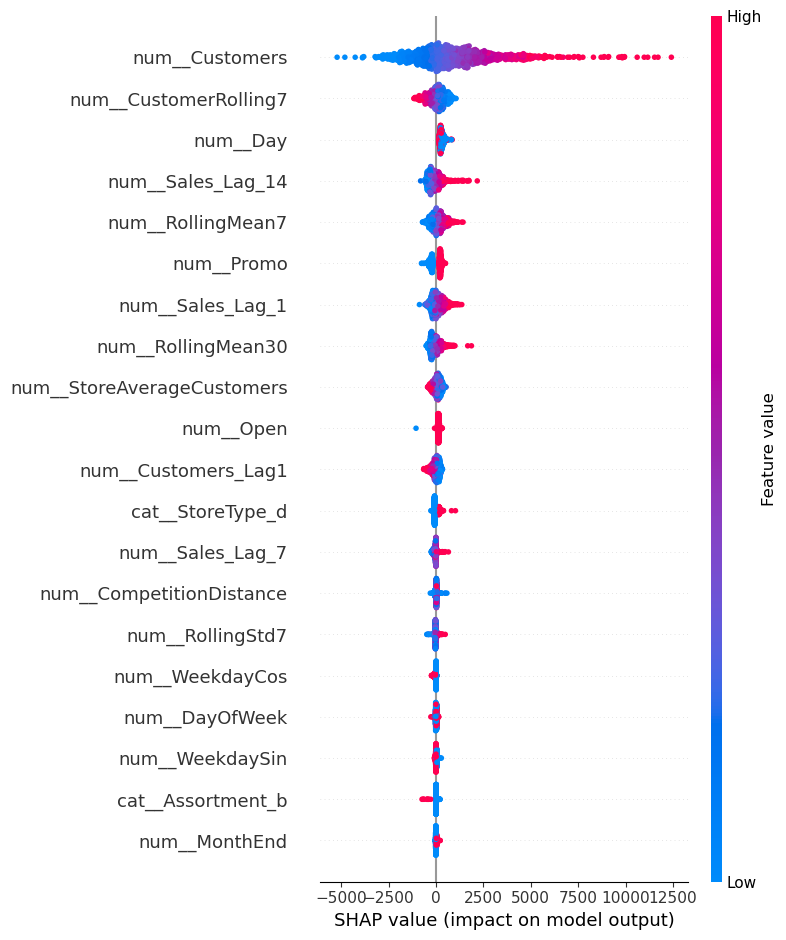

In [11]:
shap.summary_plot(
    shap_values,
    sample,
    feature_names=feature_names
)

**Bar Plot**

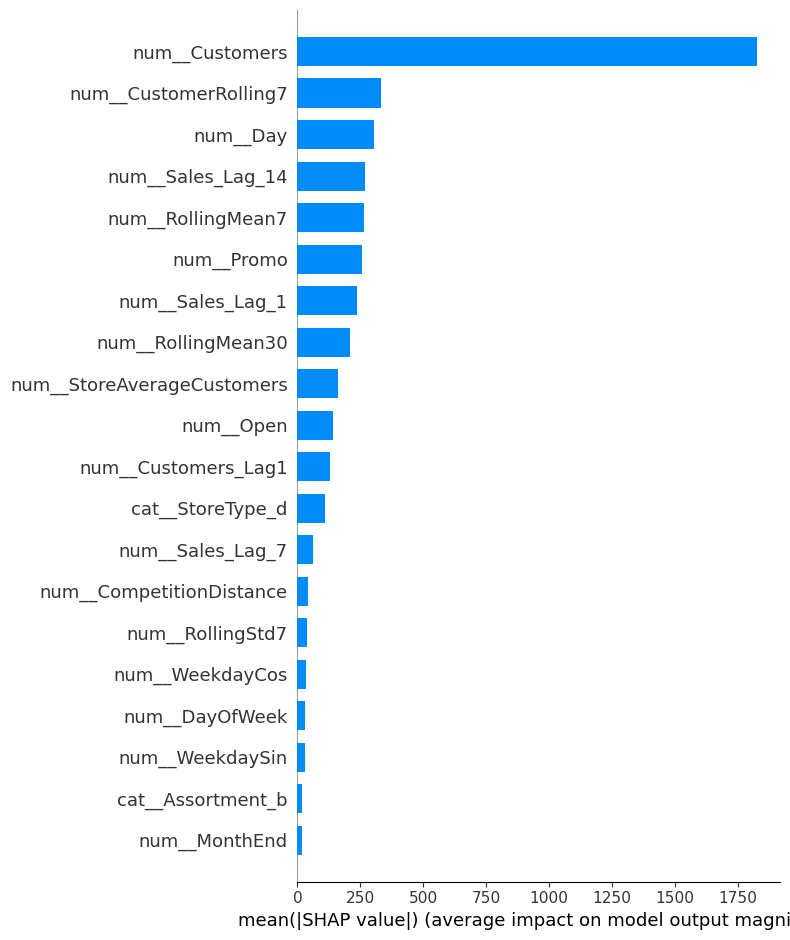

In [12]:
shap.summary_plot(
    shap_values,
    sample,
    feature_names=feature_names,
    plot_type="bar"
)

**Explain One Prediction**

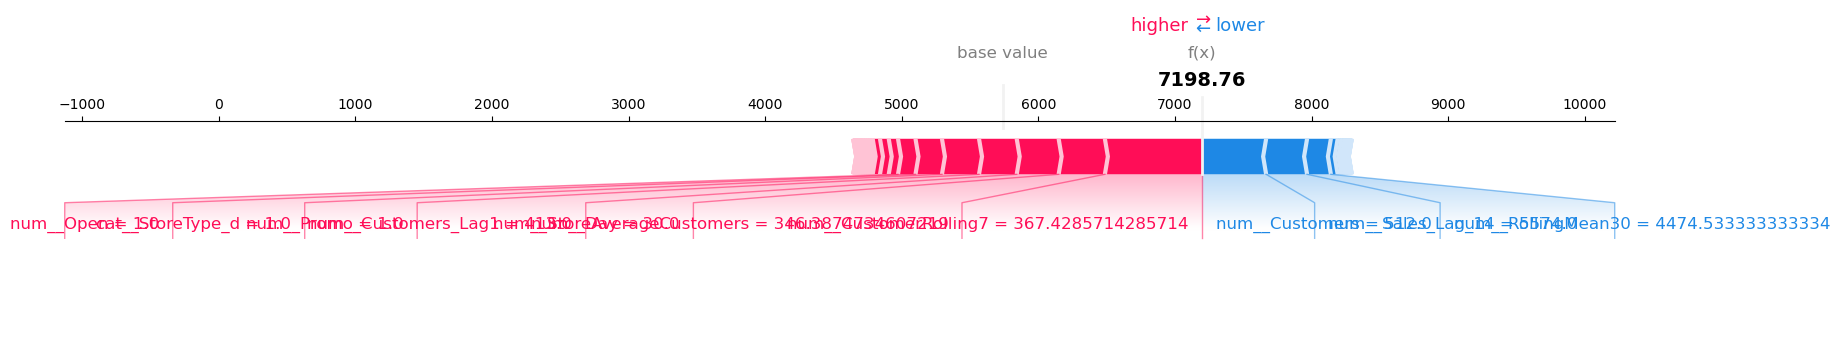

In [15]:
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    sample[0],
    feature_names=feature_names,
    matplotlib=True
)

**Waterfall Plot**

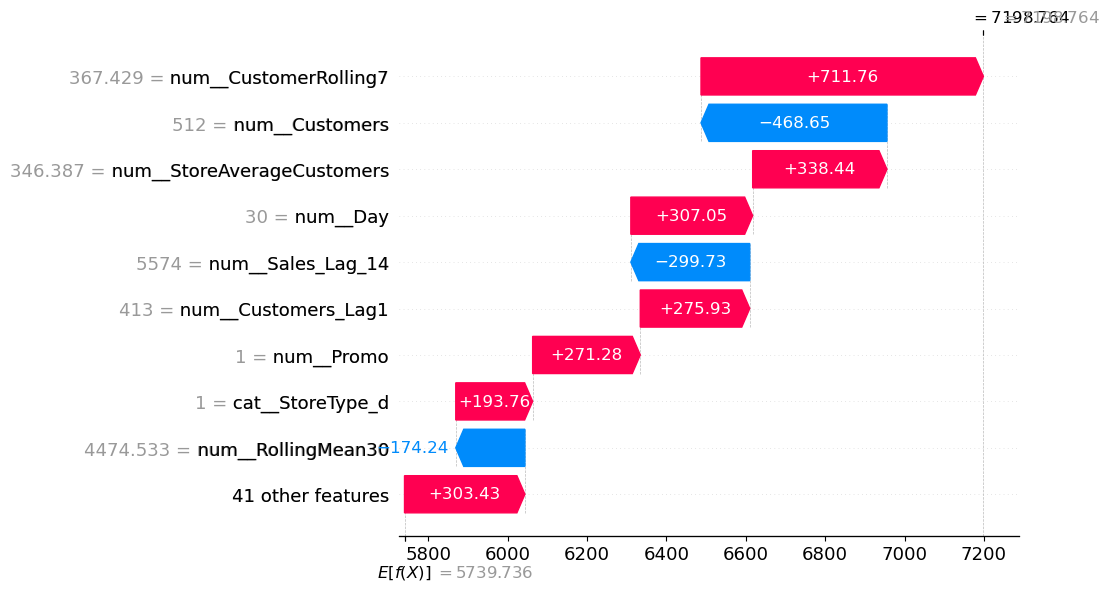

In [16]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=sample[0],
        feature_names=feature_names
    )
)

**Dependence Plot**

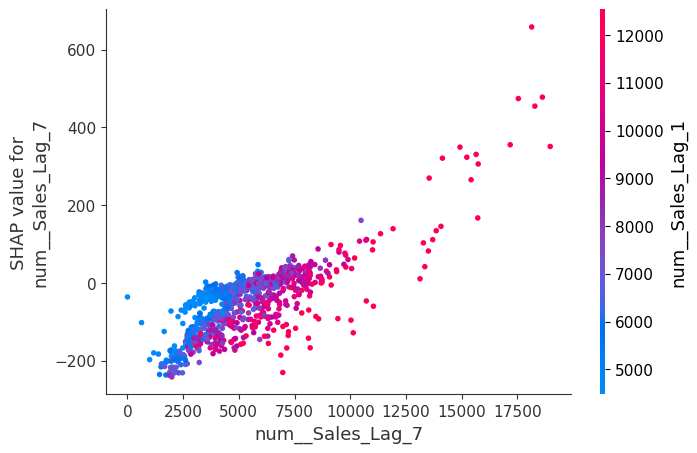

In [17]:
shap.dependence_plot(
    "num__Sales_Lag_7",
    shap_values,
    sample,
    feature_names=feature_names
)

In [18]:
plt.savefig("../images/shap_summary.png", dpi=300)

<Figure size 640x480 with 0 Axes>